In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [47]:
import numpy as np
from scipy.optimize import minimize

# Define the Rosenbrock function
def rosenbrock(params):
    x, y = params
    a = 1
    b = 100
    return (a - x)**2 + b * (y - x**2)**2

# Define the gradient of the Rosenbrock function
def rosenbrock_gradient(params):
    x, y = params
    df_dx = -2 * (1 - x) - 400 * x * (y - x**2)
    df_dy = 200 * (y - x**2)
    return np.array([df_dx, df_dy])

# Initial guess for optimization
initial_guess_rosenbrock = np.array([0.0, 0.0])

# Perform the optimization
result_rosenbrock = minimize(rosenbrock, initial_guess_rosenbrock, method='Nelder-Mead') # Nelder-Mead is a good choice for non-convex functions

print("Rosenbrock function optimization result:")
print(f"Minimum found at: x={result_rosenbrock.x[0]:.2f}, y={result_rosenbrock.x[1]:.2f}")
print(f"Minimum function value: {result_rosenbrock.fun:.2f}")

Rosenbrock function optimization result:
Minimum found at: x=1.00, y=1.00
Minimum function value: 0.00


In [66]:
import numpy as np
from scipy.optimize import minimize

# Define the 1D simplified Ackley function
def ackley_1d(x):
    # Handle x = 0 by setting f(0) = 0 or slightly exceeding zero where applicable to avoid domain errors
    # For the sqrt(x^2), abs(x) is fine. For cos(2*pi*x), 0 is fine.
    # The problem description mentions handling x=0 by setting f(0)=0. However, the formula provided
    # does not inherently cause a domain error at x=0 for sqrt(x^2) or cos(2*pi*x).
    # If there was a log(x) or 1/x, special handling would be more critical.
    # For sqrt(x^2), we can just use abs(x) or x if we are careful with the definition.
    # Let's directly implement the formula.

    term1 = -20 * np.exp(-0.2 * np.sqrt(x**2))
    term2 = -np.exp(np.cos(2 * np.pi * x))
    return term1 + term2 + 20 + np.exp(1)

# Define the gradient of the 1D simplified Ackley function
def ackley_1d_gradient(params):
    x_val = params[0]
    if np.isclose(x_val, 0):
        return np.array([0.0])

    # Derivative of -20 * exp(-0.2 * sqrt(x^2)) = -20 * exp(-0.2 * |x|) -> 4 * exp(-0.2 * |x|) * sign(x)
    grad_term1 = 4 * np.exp(-0.2 * np.abs(x_val)) * np.sign(x_val)

    # Derivative of -exp(cos(2 * pi * x)) -> -exp(cos(2*pi*x)) * (-sin(2*pi*x) * 2*pi)
    grad_term2 = 2 * np.pi * np.sin(2 * np.pi * x_val) * np.exp(np.cos(2 * np.pi * x_val))

    return np.array([grad_term1 + grad_term2])


# Initial guess for optimization
# The Ackley function has many local minima, so the initial guess is important.
# Let's try a few different initial guesses to explore.
initial_guesses_ackley = [-2.0, 0.0, 1.0]

print("Ackley function (1D simplified) optimization results:")
for i, guess in enumerate(initial_guesses_ackley):
    result_ackley = minimize(ackley_1d, np.array([guess]), method='Nelder-Mead')
    print(f"--- Initial guess: {guess} ---")
    print(f"Minimum found at: x={result_ackley.x[0]:.4f}")
    print(f"Minimum function value: {result_ackley.fun:.4f}")

Ackley function (1D simplified) optimization results:
--- Initial guess: -2.0 ---
Minimum found at: x=-1.9744
Minimum function value: 6.5596
--- Initial guess: 0.0 ---
Minimum found at: x=0.0000
Minimum function value: 0.0000
--- Initial guess: 1.0 ---
Minimum found at: x=0.9685
Minimum function value: 3.5745


In [49]:
def gradient_descent_rosenbrock(
    initial_point,
    learning_rate,
    max_iterations=10000,
    tolerance=1e-8
):

    x = np.array(initial_point, dtype=float)

    history = []

    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(max_iterations):

        # Current function value
        current_value = rosenbrock(x)

        # Store current value
        history.append(current_value)

        # Calculate gradient
        gradient = rosenbrock_gradient(x)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            status = "Converged"
            break

        # Start with the requested learning rate
        step_size = learning_rate

        # Calculate proposed update
        new_x = x - step_size * gradient

        # Backtracking:
        # Reduce the step size if the new point is worse
        while (
            not np.all(np.isfinite(new_x))
            or rosenbrock(new_x) > current_value
        ):

            step_size = step_size * 0.5

            new_x = x - step_size * gradient

            # Prevent step size from becoming too small
            if step_size < 1e-12:
                status = "Failed to find stable step"
                break

        if status == "Failed to find stable step":
            break

        # Update parameters
        x = new_x

        # Check whether we reached the minimum
        if rosenbrock(x) < tolerance:
            status = "Converged"
            break

    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        rosenbrock(x),
        history,
        iteration + 1,
        execution_time,
        status
    )

In [50]:
initial_point = np.array([-1.5, 2.0])

learning_rates = [0.01, 0.05, 0.1]

gd_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = gradient_descent_rosenbrock(
        initial_point,
        lr
    )

    gd_results.append({
        "Optimizer": "Gradient Descent",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })

gd_results_df = pd.DataFrame(gd_results)

display(gd_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Gradient Descent,0.01,"[0.9999003489869744, 0.999800157061169]",9.960667e-09,6614,0.465102,Converged
1,Gradient Descent,0.05,"[0.999900243590124, 0.9997998386440772]",9.994702e-09,8470,0.549710,Converged
2,Gradient Descent,0.10,"[0.999900243590124, 0.9997998386440772]",9.994702e-09,8470,0.597312,Converged


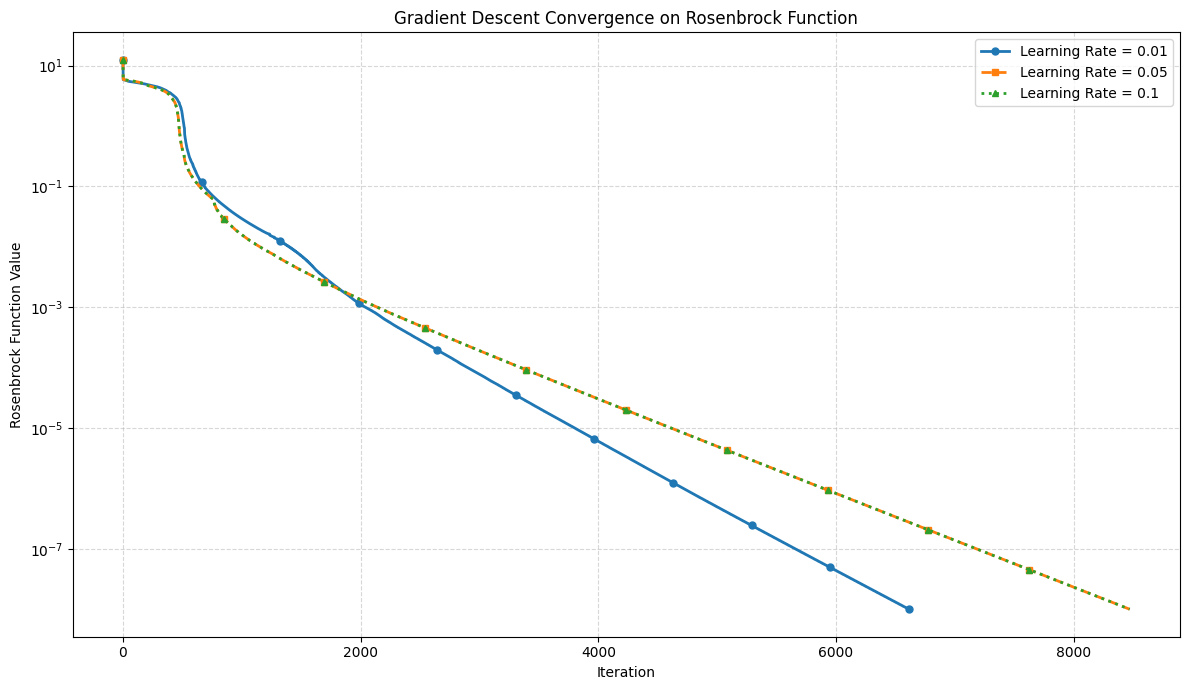

In [51]:
# ============================================================
# Gradient Descent Convergence Plot
# ============================================================

plt.figure(figsize=(12, 7))

line_styles = ['-', '--', ':']
markers = ['o', 's', '^']

for i, lr in enumerate(learning_rates):

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = gradient_descent_rosenbrock(
        initial_point,
        lr
    )

    # Create iteration numbers
    iteration_numbers = np.arange(1, len(history) + 1)

    # Plot each learning rate with different style
    plt.plot(
        iteration_numbers,
        history,
        linestyle=line_styles[i],
        marker=markers[i],
        markevery=max(1, len(history) // 10),
        linewidth=2,
        markersize=5,
        label=f"Learning Rate = {lr}"
    )


# Log scale makes convergence easier to see
plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Rosenbrock Function Value")

plt.title(
    "Gradient Descent Convergence on Rosenbrock Function"
)

plt.legend()

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [52]:
def sgd_momentum_rosenbrock(
    initial_point,
    learning_rate,
    beta=0.9,
    max_iterations=10000,
    tolerance=1e-2,
    gradient_clip=1.0
):

    # Initial parameters
    x = np.array(initial_point, dtype=float)

    # Initial velocity
    velocity = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(max_iterations):

        # Current function value
        current_value = rosenbrock(x)

        # Store value
        history.append(current_value)

        # Calculate gradient
        gradient = rosenbrock_gradient(x)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            status = "Converged"
            break

        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ----------------------------------------------------
        # Momentum update
        # ----------------------------------------------------

        velocity = (
            beta * velocity
            + (1 - beta) * gradient
        )

        # ----------------------------------------------------
        # Parameter update
        # ----------------------------------------------------

        x = x - learning_rate * velocity

        # Check numerical stability
        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

        # Check if function is sufficiently close to minimum
        if rosenbrock(x) < tolerance:

            status = "Converged"
            break

    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        rosenbrock(x),
        history,
        iteration + 1,
        execution_time,
        status
    )

In [53]:
sgdm_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = sgd_momentum_rosenbrock(
        initial_point,
        lr
    )

    sgdm_results.append({
        "Optimizer": "SGD with Momentum",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


sgdm_results_df = pd.DataFrame(sgdm_results)

display(sgdm_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,SGD with Momentum,0.01,"[0.900506966192946, 0.8104897543480012]",0.009917,627,0.023483,Converged
1,SGD with Momentum,0.05,"[0.9047283981270757, 0.8183671707458727]",0.009079,141,0.003723,Converged
2,SGD with Momentum,0.10,"[0.9280015286395668, 0.8545291560787335]",0.009616,135,0.003978,Converged


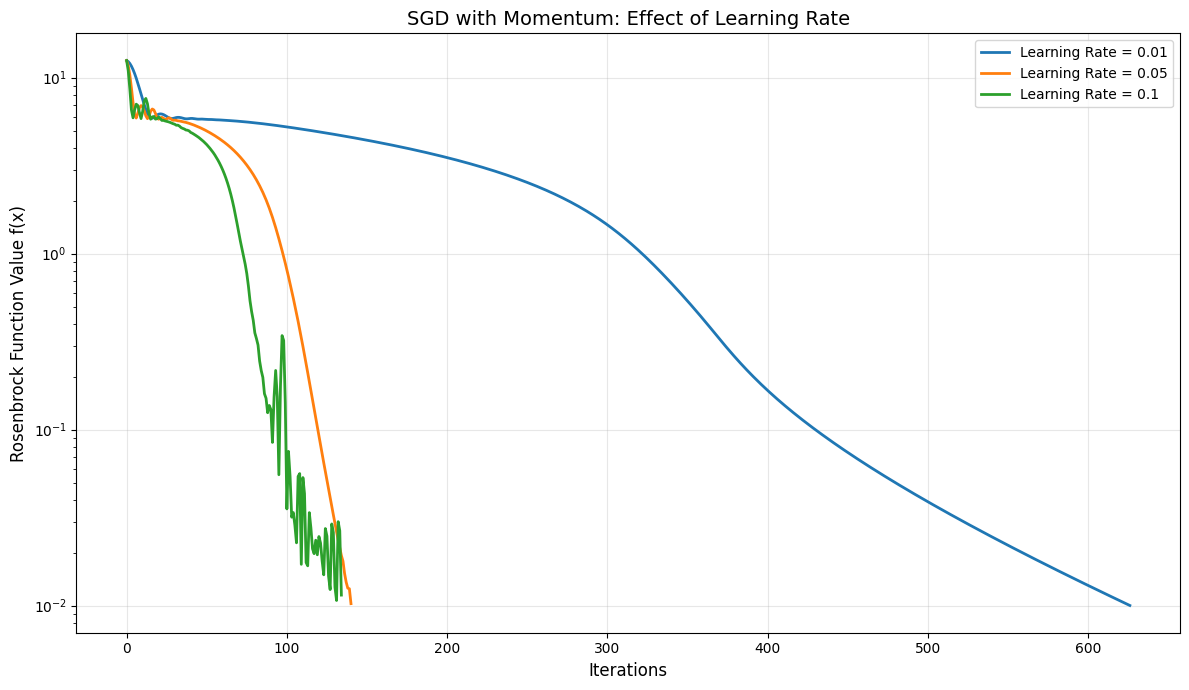

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run SGD with Momentum again to get its history
    x_best, f_best, history, iterations, execution_time, status = \
        sgd_momentum_rosenbrock(initial_point, lr)

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Rosenbrock Function Value f(x)", fontsize=12)
plt.title("SGD with Momentum: Effect of Learning Rate", fontsize=14)

plt.yscale("log")   # Makes differences much clearer
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
def adam_rosenbrock(
    initial_point,
    learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-3,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # First moment
    m = np.zeros_like(x)

    # Second moment
    v = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = rosenbrock(x)

        # Store function value
        history.append(current_value)

        # Calculate gradient
        gradient = rosenbrock_gradient(x)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:

            status = "Converged"
            break

        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ----------------------------------------------------
        # First moment estimate
        # ----------------------------------------------------

        m = beta1 * m + (1 - beta1) * gradient

        # ----------------------------------------------------
        # Second moment estimate
        # ----------------------------------------------------

        v = beta2 * v + (1 - beta2) * (gradient ** 2)

        # ----------------------------------------------------
        # Bias correction
        # ----------------------------------------------------

        m_hat = m / (1 - beta1 ** iteration)

        v_hat = v / (1 - beta2 ** iteration)

        # ----------------------------------------------------
        # Adam parameter update
        # ----------------------------------------------------

        x = x - learning_rate * (
            m_hat / (np.sqrt(v_hat) + epsilon)
        )

        # Numerical stability check
        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

        # Check function value
        if rosenbrock(x) < tolerance:

            status = "Converged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        rosenbrock(x),
        history,
        iteration,
        execution_time,
        status
    )

In [56]:
initial_point = np.array([-1.5, 2.0])

learning_rates = [0.01, 0.05, 0.1]
adam_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adam_rosenbrock(
        initial_point,
        lr
    )

    adam_results.append({
        "Optimizer": "Adam",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


adam_results_df = pd.DataFrame(adam_results)

display(adam_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Adam,0.01,"[0.9685201016596238, 0.9379006719100831]",0.000993,537,0.045241,Converged
1,Adam,0.05,"[0.9831929886946519, 0.9688358754783347]",0.000752,121,0.007906,Converged
2,Adam,0.10,"[0.9834958115645509, 0.9669236487985036]",0.000284,125,0.009164,Converged


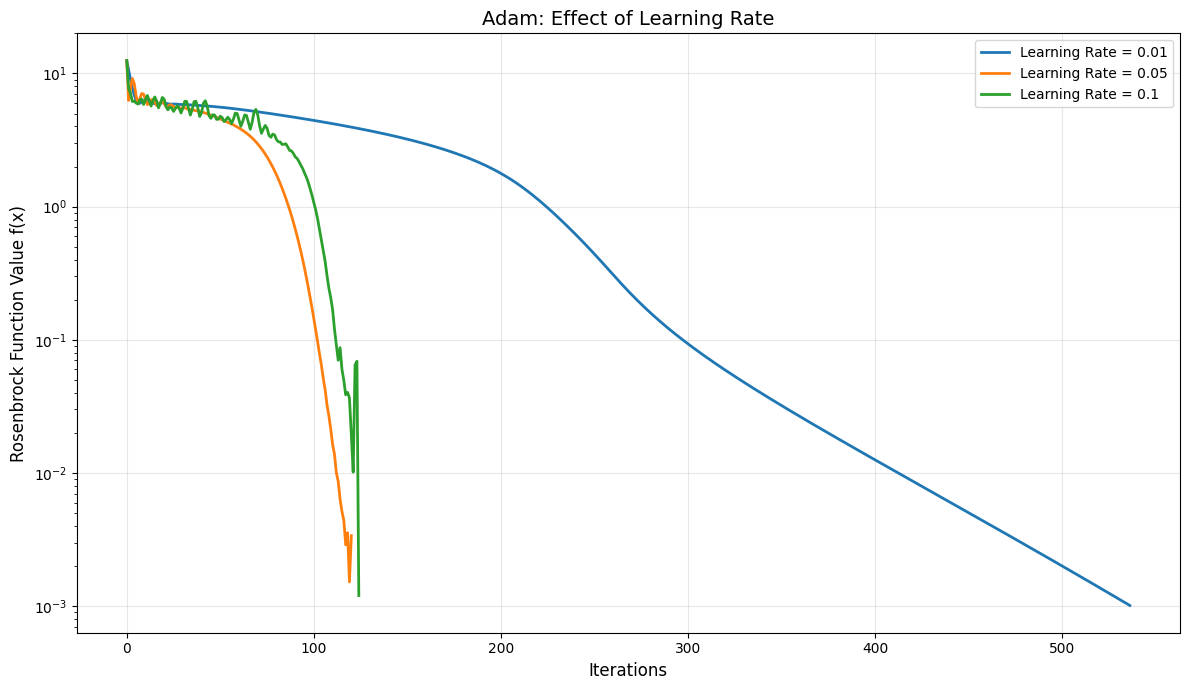

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run Adam again to get its history
    x_best, f_best, history, iterations, execution_time, status = \
        adam_rosenbrock(initial_point, lr)

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Rosenbrock Function Value f(x)", fontsize=12)
plt.title("Adam: Effect of Learning Rate", fontsize=14)

plt.yscale("log")   # Makes convergence differences clearer

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
def rmsprop_rosenbrock(
    initial_point,
    learning_rate,
    beta=0.9,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-1,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Moving average of squared gradients
    v = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = rosenbrock(x)

        # Store function value
        history.append(current_value)

        # Calculate gradient
        gradient = rosenbrock_gradient(x)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:

            status = "Converged"
            break

        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ----------------------------------------------------
        # Moving average of squared gradients
        # ----------------------------------------------------

        v = beta * v + (1 - beta) * (gradient ** 2)

        # ----------------------------------------------------
        # RMSprop parameter update
        # ----------------------------------------------------

        x = x - learning_rate * (
            gradient / (np.sqrt(v) + epsilon)
        )

        # Numerical stability check
        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

        # Check function value
        if rosenbrock(x) < tolerance:

            status = "Converged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        rosenbrock(x),
        history,
        iteration,
        execution_time,
        status
    )

In [59]:
initial_point = np.array([-1.5, 2.0])

learning_rates = [0.01, 0.05, 0.1]
rmsprop_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = rmsprop_rosenbrock(
        initial_point,
        lr
    )

    rmsprop_results.append({
        "Optimizer": "RMSprop",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


rmsprop_results_df = pd.DataFrame(rmsprop_results)

display(rmsprop_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,RMSprop,0.01,"[0.6926292761443033, 0.4728699313680588]",0.099190,670,0.029793,Converged
1,RMSprop,0.05,"[0.7484815634402366, 0.5411987337398629]",0.099460,1061,0.032082,Converged
2,RMSprop,0.10,"[0.3764308695249543, 0.1796133120542297]",0.532579,10000,0.310641,Maximum iterations reached


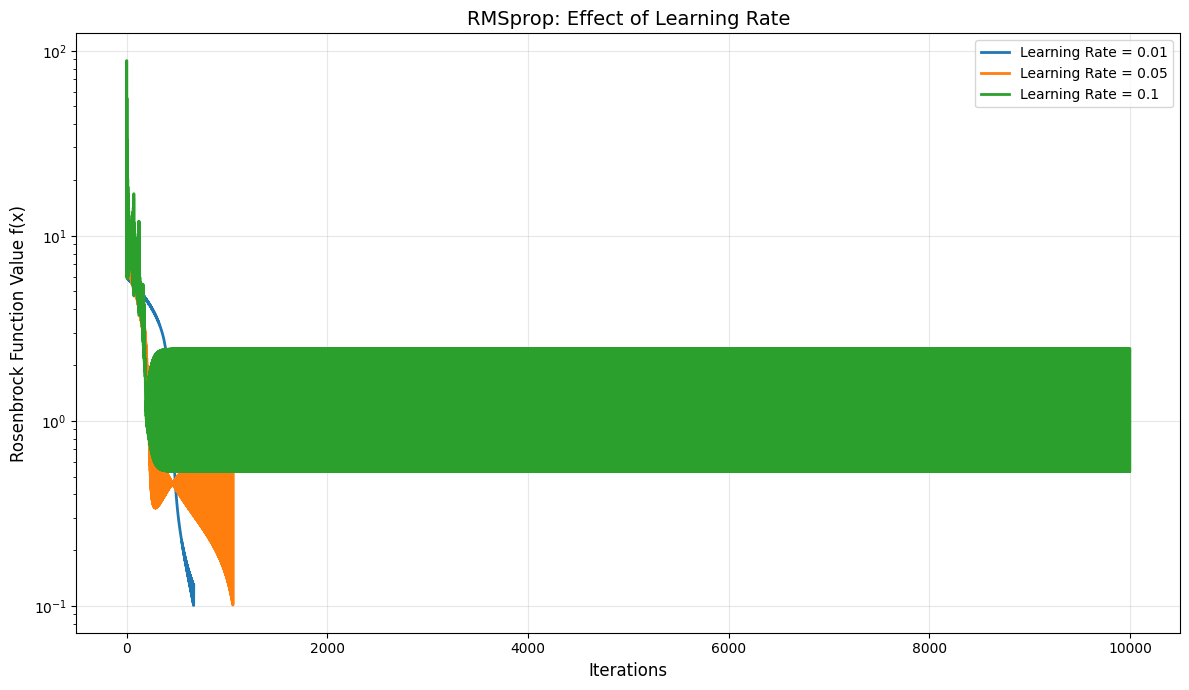

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run RMSprop again to get its history
    x_best, f_best, history, iterations, execution_time, status = \
        rmsprop_rosenbrock(initial_point, lr)

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Rosenbrock Function Value f(x)", fontsize=12)
plt.title("RMSprop: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
def adagrad_rosenbrock(
    initial_point,
    learning_rate,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-1,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Accumulated squared gradients
    G = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = rosenbrock(x)

        # Store function value
        history.append(current_value)

        # Calculate gradient
        gradient = rosenbrock_gradient(x)

        # ------------------------------------------------
        # Gradient clipping
        # ------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ------------------------------------------------
        # Accumulate squared gradients
        # ------------------------------------------------

        G = G + gradient ** 2

        # ------------------------------------------------
        # Adagrad update
        # ------------------------------------------------

        x = x - learning_rate * (
            gradient /
            (np.sqrt(G) + epsilon)
        )

        # ------------------------------------------------
        # Numerical stability
        # ------------------------------------------------

        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

        # ------------------------------------------------
        # Function value convergence
        # ------------------------------------------------

        new_value = rosenbrock(x)

        if new_value < tolerance:

            status = "Converged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        rosenbrock(x),
        history,
        iteration,
        execution_time,
        status
    )

In [62]:
learning_rates = [0.01, 0.05, 0.1]
initial_point = np.array([-1.5, 2.0])

learning_rates = [0.01, 0.05, 0.1]

adagrad_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adagrad_rosenbrock(
        initial_point,
        lr
    )

    adagrad_results.append({
        "Optimizer": "Adagrad",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


adagrad_results_df = pd.DataFrame(adagrad_results)

display(adagrad_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Adagrad,0.01,"[-0.23828613598197693, 0.07366627145365559]",1.561866,10000,0.343284,Maximum iterations reached
1,Adagrad,0.05,"[0.6844891972272231, 0.46714450816462877]",0.099738,1301,0.036204,Converged
2,Adagrad,0.10,"[0.6882313188255049, 0.4696541065991023]",0.098806,657,0.017774,Converged


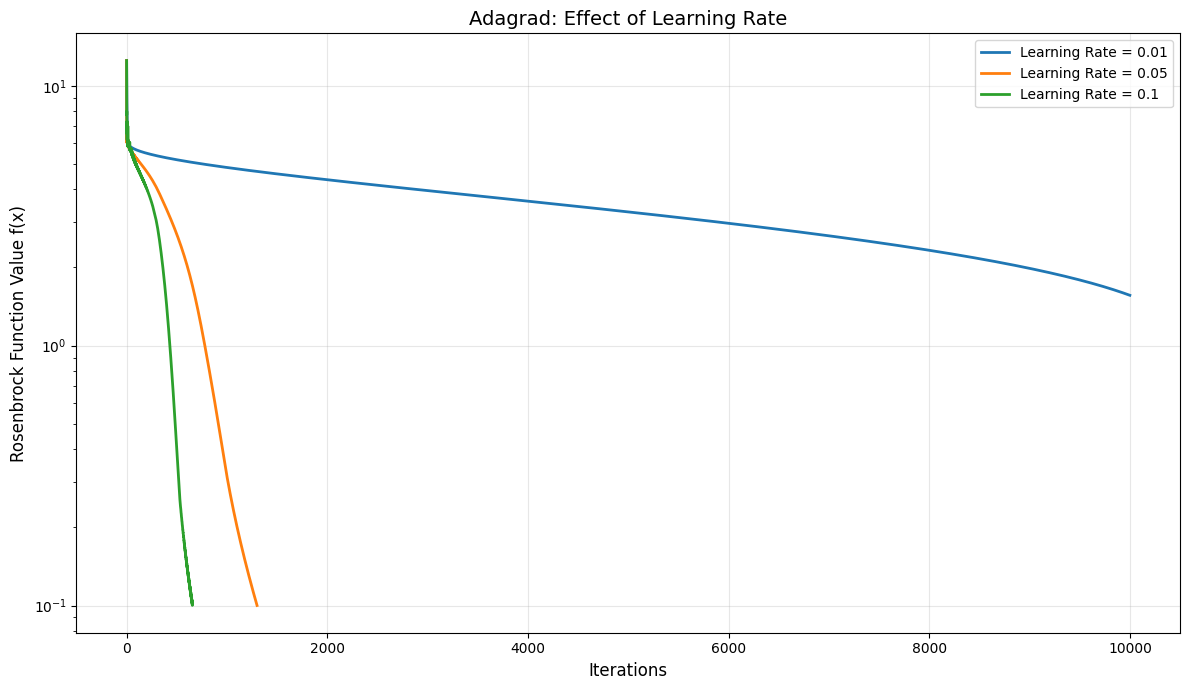

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run Adagrad again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adagrad_rosenbrock(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Rosenbrock Function Value f(x)", fontsize=12)
plt.title("Adagrad: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
def gd_ackley(
    initial_point,
    learning_rate,
    max_iterations=10000,
    tolerance=1e-4,
    gradient_clip=9.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    # ----------------------------------------------------
    # Gradient Descent loop
    # ----------------------------------------------------

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = ackley_1d(x)

        # Store function value
        history.append(current_value)

        # Calculate gradient
        gradient = ackley_1d_gradient(x)

        # ------------------------------------------------
        # Check convergence
        # ------------------------------------------------

        if (
            np.linalg.norm(gradient) < tolerance
            or current_value < tolerance
        ):

            status = "Converged"
            break

        # ------------------------------------------------
        # Gradient clipping
        # ------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ------------------------------------------------
        # Gradient Descent update
        # ------------------------------------------------

        x = x - learning_rate * gradient

        # ------------------------------------------------
        # Numerical stability check
        # ------------------------------------------------

        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

    # ----------------------------------------------------
    # End timer
    # ----------------------------------------------------

    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        ackley_1d(x),
        history,
        iteration,
        execution_time,
        status
    )

In [67]:
initial_point = np.array([-2.0])

learning_rates = [0.01, 0.05, 0.1]

gd_ackley_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = gd_ackley(
        initial_point,
        lr
    )

    gd_ackley_results.append({
        "Optimizer": "Gradient Descent",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })

gd_ackley_results_df = pd.DataFrame(
    gd_ackley_results
)

display(gd_ackley_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Gradient Descent,0.01,[-1.974451806067235],[6.559645375629525],4,0.000935,Converged
1,Gradient Descent,0.05,[-1.8857036748622735],[6.8784717049033155],10000,1.078003,Maximum iterations reached
2,Gradient Descent,0.10,[8.835854848954217e-06],[3.534757727097215e-05],1993,0.116552,Converged


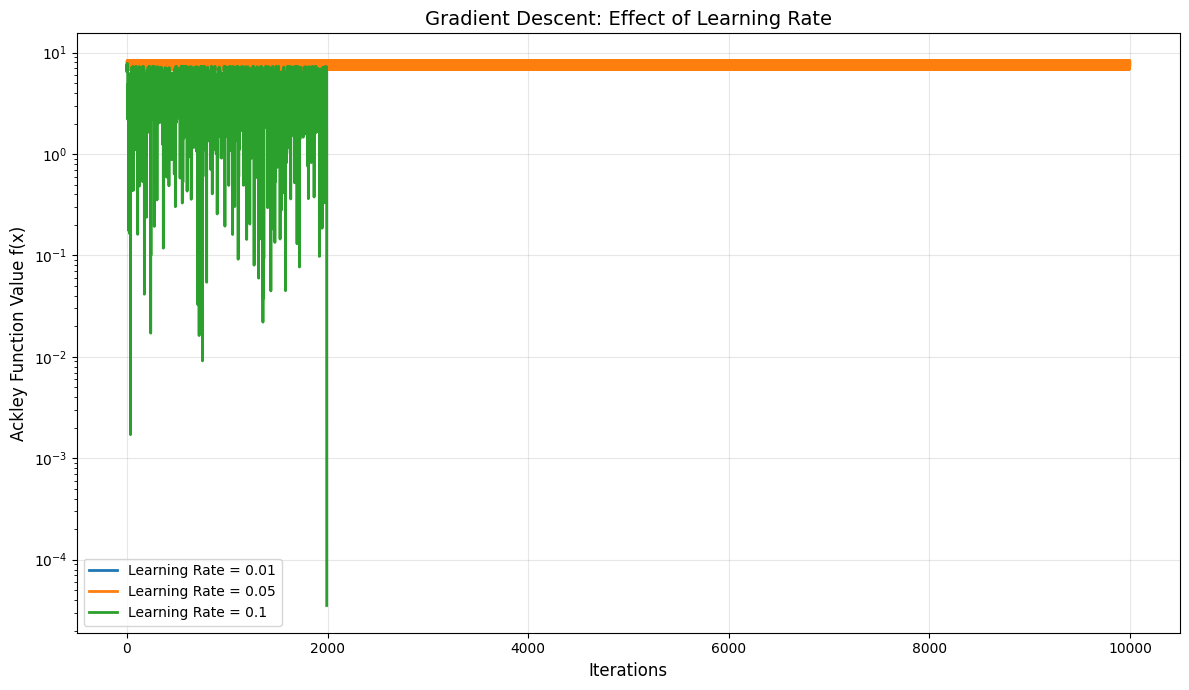

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run GD again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = gd_ackley(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Ackley Function Value f(x)", fontsize=12)
plt.title("Gradient Descent: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
def sgd_momentum_ackley(
    initial_point,
    learning_rate,
    beta=0.9,
    max_iterations=10000,
    tolerance=1e-1,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Momentum velocity
    velocity = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # ------------------------------------------------
        # Current function value
        # ------------------------------------------------

        current_value = ackley_1d(x)

        # Store function value
        history.append(current_value)

        # ------------------------------------------------
        # Check convergence
        # ------------------------------------------------

        if current_value < tolerance:

            status = "Converged"
            break

        # ------------------------------------------------
        # Calculate gradient
        # ------------------------------------------------

        gradient = ackley_1d_gradient(x)

        # ------------------------------------------------
        # Gradient clipping
        # ------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ------------------------------------------------
        # Momentum update
        # ------------------------------------------------

        velocity = (
            beta * velocity
            + gradient
        )

        # ------------------------------------------------
        # Parameter update
        # ------------------------------------------------

        x = (
            x
            - learning_rate * velocity
        )

        # ------------------------------------------------
        # Numerical stability check
        # ------------------------------------------------

        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = (
        end_time - start_time
    )

    return (
        x,
        ackley_1d(x),
        history,
        iteration,
        execution_time,
        status
    )

In [85]:
initial_point = np.array([-0.6])

learning_rates = [0.01, 0.05, 0.1]

sgd_momentum_ackley_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = sgd_momentum_ackley(
        initial_point,
        lr
    )

    sgd_momentum_ackley_results.append({
        "Optimizer": "SGD with Momentum",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


sgd_momentum_ackley_results_df = pd.DataFrame(
    sgd_momentum_ackley_results
)

display(sgd_momentum_ackley_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,SGD with Momentum,0.01,[0.006930725807185421],[0.030279468720707303],25,0.008775,Converged
1,SGD with Momentum,0.05,[-0.0026899873402019964],[0.011145280326758655],31,0.008128,Converged
2,SGD with Momentum,0.10,[-0.007500600853509565],[0.03299635232177822],15,0.004013,Converged


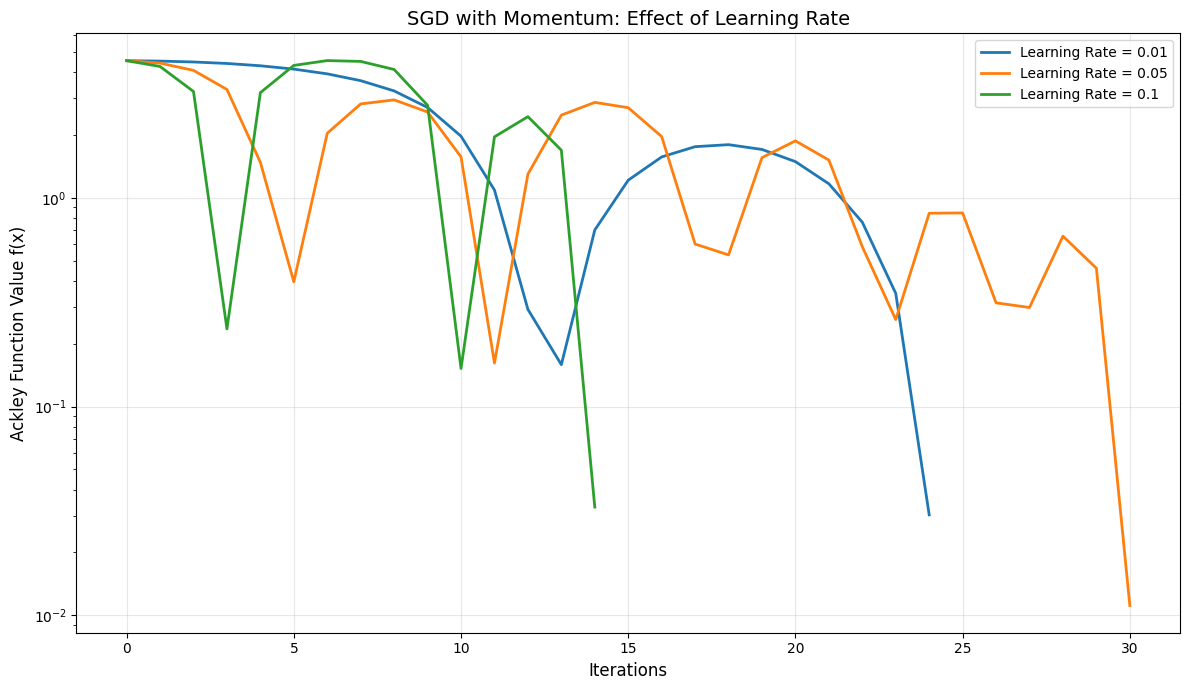

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run SGD with Momentum again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = sgd_momentum_ackley(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Ackley Function Value f(x)", fontsize=12)
plt.title("SGD with Momentum: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [87]:
def adam_ackley(
    initial_point,
    learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-2,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # First moment
    m = np.zeros_like(x)

    # Second moment
    v = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = ackley_1d(x)

        # Store function value
        history.append(current_value)

        # ------------------------------------------------
        # Check convergence
        # ------------------------------------------------

        if current_value < tolerance:

            status = "Converged"
            break

        # ------------------------------------------------
        # Calculate gradient
        # ------------------------------------------------

        gradient = ackley_1d_gradient(x)

        # ------------------------------------------------
        # Gradient clipping
        # ------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ------------------------------------------------
        # First moment estimate
        # ------------------------------------------------

        m = (
            beta1 * m
            + (1 - beta1) * gradient
        )

        # ------------------------------------------------
        # Second moment estimate
        # ------------------------------------------------

        v = (
            beta2 * v
            + (1 - beta2) * gradient ** 2
        )

        # ------------------------------------------------
        # Bias correction
        # ------------------------------------------------

        m_hat = (
            m / (1 - beta1 ** iteration)
        )

        v_hat = (
            v / (1 - beta2 ** iteration)
        )

        # ------------------------------------------------
        # Adam parameter update
        # ------------------------------------------------

        x = x - learning_rate * (
            m_hat /
            (np.sqrt(v_hat) + epsilon)
        )

        # ------------------------------------------------
        # Numerical stability check
        # ------------------------------------------------

        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = (
        end_time - start_time
    )

    return (
        x,
        ackley_1d(x),
        history,
        iteration,
        execution_time,
        status
    )

In [88]:
initial_point = np.array([0.003])

learning_rates = [0.01, 0.05, 0.1]

adam_ackley_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adam_ackley(
        initial_point,
        lr
    )

    adam_ackley_results.append({
        "Optimizer": "Adam",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


adam_ackley_results_df = pd.DataFrame(
    adam_ackley_results
)

display(adam_ackley_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Adam,0.01,[0.0021638443208169835],[0.00890472193234304],8,0.001641,Converged
1,Adam,0.05,[-0.0011807783959150789],[0.004797364795117165],8,0.001539,Converged
2,Adam,0.10,[0.0023657466861903248],[0.00976102999294115],29,0.005526,Converged


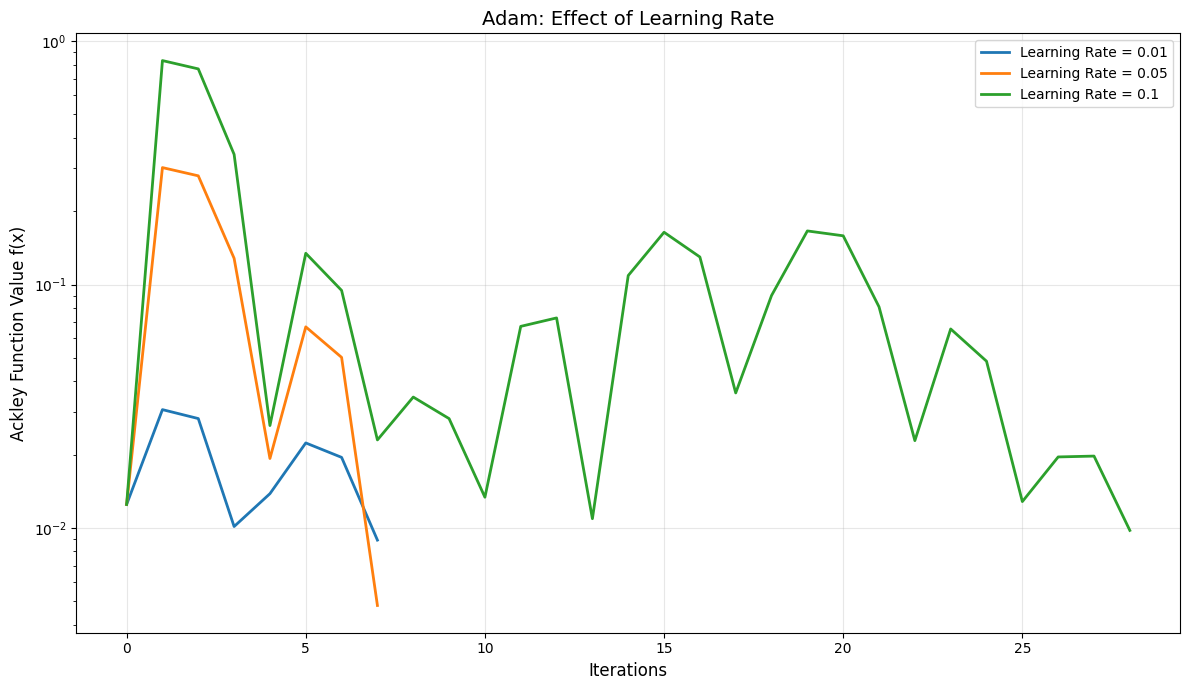

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run Adam again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adam_ackley(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Ackley Function Value f(x)", fontsize=12)
plt.title("Adam: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [90]:
def rmsprop_ackley(
    initial_point,
    learning_rate,
    beta=0.9,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-1,
    gradient_clip=10.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Moving average of squared gradients
    v = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # ------------------------------------------------
        # Current function value
        # ------------------------------------------------

        current_value = ackley_1d(x)

        # Store function value
        history.append(current_value)

        # ------------------------------------------------
        # Check convergence
        # ------------------------------------------------

        if current_value < tolerance:

            status = "Converged"
            break

        # ------------------------------------------------
        # Calculate gradient
        # ------------------------------------------------

        gradient = ackley_1d_gradient(x)

        # ------------------------------------------------
        # Gradient clipping
        # ------------------------------------------------

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # ------------------------------------------------
        # Moving average of squared gradients
        # ------------------------------------------------

        v = (
            beta * v
            + (1 - beta) * gradient ** 2
        )

        # ------------------------------------------------
        # RMSprop parameter update
        # ------------------------------------------------

        x = x - learning_rate * (
            gradient /
            (np.sqrt(v) + epsilon)
        )

        # ------------------------------------------------
        # Numerical stability check
        # ------------------------------------------------

        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

    # ----------------------------------------------------
    # End timer
    # ----------------------------------------------------

    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        ackley_1d(x),
        history,
        iteration,
        execution_time,
        status
    )

In [91]:
initial_point = np.array([0.5])

learning_rates = [0.01, 0.05, 0.1]

rmsprop_ackley_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = rmsprop_ackley(
        initial_point,
        lr
    )

    rmsprop_ackley_results.append({
        "Optimizer": "RMSprop",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })


rmsprop_ackley_results_df = pd.DataFrame(
    rmsprop_ackley_results
)

display(rmsprop_ackley_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,RMSprop,0.01,[0.013912340346418554],[0.0659310447262027],36,0.005070,Converged
1,RMSprop,0.05,[-0.02499999996223095],[0.1330118043544748],10000,0.878243,Maximum iterations reached
2,RMSprop,0.10,[-0.04999999994435757],[0.32884220564281863],10000,0.655147,Maximum iterations reached


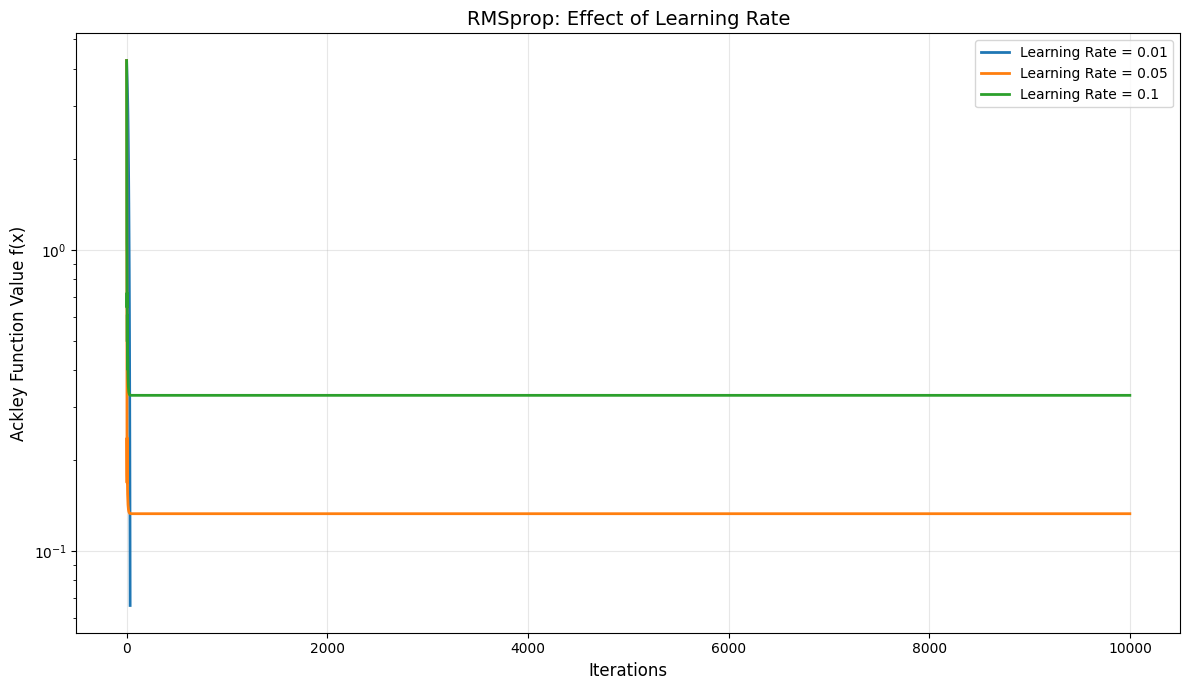

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run RMSprop again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = rmsprop_ackley(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Ackley Function Value f(x)", fontsize=12)
plt.title("RMSprop: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
def adagrad_ackley(
    initial_point,
    learning_rate,
    epsilon=1e-8,
    max_iterations=10000,
    tolerance=1e-1,
    gradient_clip=1.0
):

    # Initial point
    x = np.array(initial_point, dtype=float)

    # Accumulated squared gradients
    G = np.zeros_like(x)

    # Store function values
    history = []

    # Start timer
    start_time = time.perf_counter()

    status = "Maximum iterations reached"

    for iteration in range(1, max_iterations + 1):

        # Current function value
        current_value = ackley_1d(x)

        # Store function value
        history.append(current_value)

        # Check convergence
        if current_value < tolerance:

            status = "Converged"
            break

        # Calculate gradient
        gradient = ackley_1d_gradient(x)

        # Gradient clipping
        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm > gradient_clip:

            gradient = (
                gradient / gradient_norm
            ) * gradient_clip

        # Accumulate squared gradients
        G = G + gradient ** 2

        # Adagrad update
        x = x - learning_rate * (
            gradient /
            (np.sqrt(G) + epsilon)
        )

        # Numerical stability check
        if not np.all(np.isfinite(x)):

            status = "Diverged"
            break

    # End timer
    end_time = time.perf_counter()

    execution_time = end_time - start_time

    return (
        x,
        ackley_1d(x),
        history,
        iteration,
        execution_time,
        status
    )

In [99]:
initial_point = np.array([-0.6])

learning_rates = [0.01, 0.05, 0.1]

adagrad_ackley_results = []

for lr in learning_rates:

    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adagrad_ackley(
        initial_point,
        lr
    )

    adagrad_ackley_results.append({
        "Optimizer": "Adagrad",
        "Learning Rate": lr,
        "Optimal x": x_best,
        "Minimum f(x)": f_best,
        "Iterations": iterations,
        "Time (seconds)": execution_time,
        "Status": status
    })

adagrad_ackley_results_df = pd.DataFrame(
    adagrad_ackley_results
)

display(adagrad_ackley_results_df)

,Optimizer,Learning Rate,Optimal x,Minimum f(x),Iterations,Time (seconds),Status
0,Adagrad,0.01,[-0.019792643586038897],[0.09992610805699487],885,0.172946,Converged
1,Adagrad,0.05,[-0.0134687991738923],[0.06351329453123755],44,0.007316,Converged
2,Adagrad,0.10,[-0.011146555522347917],[0.05119229284494908],14,0.005148,Converged


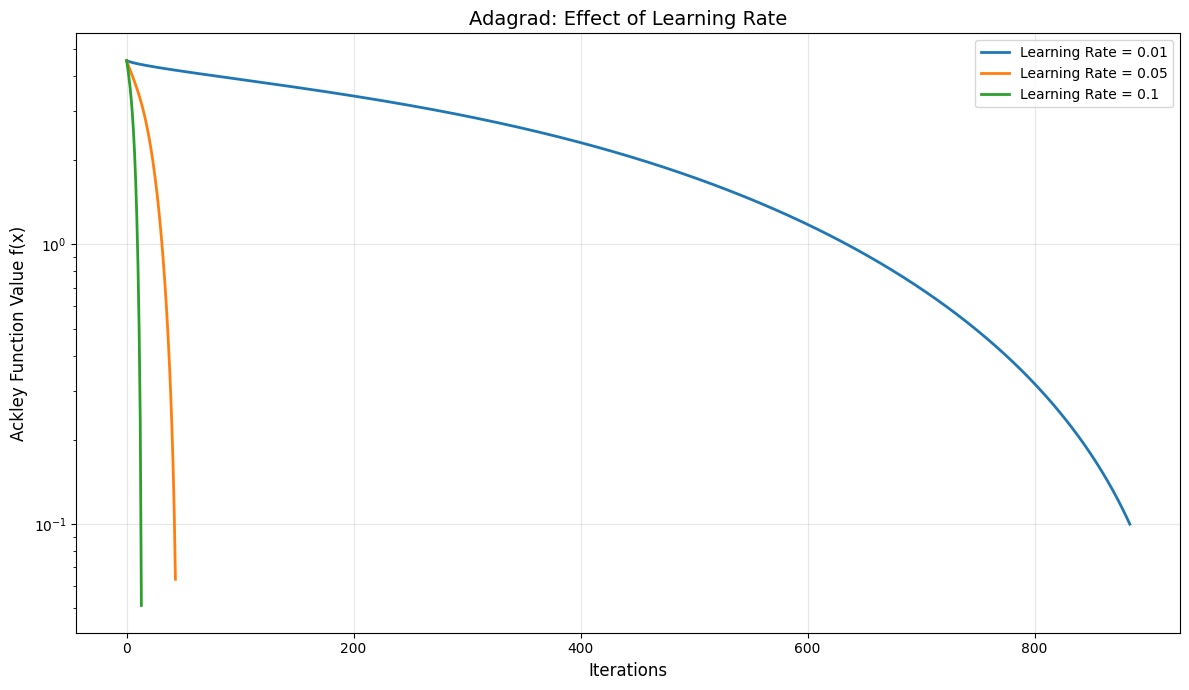

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for lr in learning_rates:

    # Run Adagrad again to get its history
    (
        x_best,
        f_best,
        history,
        iterations,
        execution_time,
        status
    ) = adagrad_ackley(
        initial_point,
        lr
    )

    # Plot objective value vs iteration
    plt.plot(
        range(len(history)),
        history,
        label=f"Learning Rate = {lr}",
        linewidth=2
    )

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Ackley Function Value f(x)", fontsize=12)
plt.title("Adagrad: Effect of Learning Rate", fontsize=14)

plt.yscale("log")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()